<a href="https://colab.research.google.com/github/RaheemKProjects/Raheem-North-Star-Analytical-Workflow/blob/main/03_python_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/[USERNAME]/northstar-analytics-cw1/blob/main/notebooks/03_python_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 03 — Python Data Processing: Pandas, NumPy and Visualisation

**NorthStar Analytics — Coursework 1, Section 5**

Feature engineering, anomaly removal, NumPy vectorised statistics, Welch's t-test, and seaborn visualisations.

In [ ]:
!pip install seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings('ignore')
np.random.seed(42)

plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 120,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})
sns.set_style('whitegrid')

In [ ]:
# Load datasets
customers  = pd.read_csv('customers.csv',  parse_dates=['signup_date'])
orders     = pd.read_csv('orders.csv',     parse_dates=['order_created_at'])
deliveries = pd.read_csv('deliveries.csv',
                         parse_dates=['dispatch_time','delivery_completed_at'])
drivers    = pd.read_csv('drivers.csv')
vehicles   = pd.read_csv('vehicles.csv',   parse_dates=['commission_date'])
hubs       = pd.read_csv('hubs.csv')
incidents  = pd.read_csv('incidents.csv',  parse_dates=['reported_at'])
complaints = pd.read_csv('complaints.csv', parse_dates=['created_at'])
app_events = pd.read_csv('app_events.csv', parse_dates=['event_timestamp'])

print('Loaded:')
for n, df in [('customers', customers), ('orders', orders),
              ('deliveries', deliveries), ('drivers', drivers),
              ('vehicles', vehicles), ('hubs', hubs),
              ('incidents', incidents), ('complaints', complaints),
              ('app_events', app_events)]:
    print(f'  {n:12s}: {df.shape}')

Loaded:
  customers   : (650, 9)
  orders      : (1250, 11)
  deliveries  : (950, 13)
  drivers     : (170, 8)
  vehicles    : (120, 8)
  hubs        : (8, 5)
  incidents   : (280, 7)
  complaints  : (320, 10)
  app_events  : (640, 10)


## 1. Zone normalisation

In [ ]:
def normalise_zone(s: pd.Series) -> pd.Series:
    mapping = {'ctr': 'Central', 'central': 'Central', 'airport': 'Airport',
               'north': 'North', 'south': 'South', 'east': 'East',
               'west': 'West', 'riverside': 'Riverside'}
    return s.str.strip().str.lower().map(lambda x: mapping.get(x, str(x).title()))

orders['pickup_zone']    = normalise_zone(orders['pickup_zone'])
orders['dropoff_zone']   = normalise_zone(orders['dropoff_zone'])
customers['home_zone']   = normalise_zone(customers['home_zone'])
drivers['base_zone']     = normalise_zone(drivers['base_zone'])
vehicles['assigned_zone']= normalise_zone(vehicles['assigned_zone'])
hubs['zone']             = normalise_zone(hubs['zone'])

print('Distinct zones:', sorted(orders['pickup_zone'].unique()))

Distinct zones: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


## 2. Feature engineering and anomaly removal

In [ ]:
deliveries['actual_duration_hrs'] = (
    deliveries['delivery_completed_at'] - deliveries['dispatch_time']
).dt.total_seconds() / 3600

anomalies = deliveries[deliveries['actual_duration_hrs'] < 0]
print(f'Anomalous duration records (completion before dispatch): {len(anomalies)}')
deliveries = deliveries[
    (deliveries['actual_duration_hrs'].isna()) |
    (deliveries['actual_duration_hrs'] >= 0)
].copy()

# Build master dataframe
master = (orders
          .merge(deliveries, on='order_id', how='inner')
          .merge(drivers, on='driver_id', how='left')
          .merge(vehicles, on='vehicle_id', how='left')
          .merge(hubs, on='hub_id', how='left'))

master['within_window'] = (
    master['actual_duration_hrs'] <= master['promised_window_hours']
)
print(f'Master shape: {master.shape}')
print(f'Promise honour rate: {master["within_window"].mean()*100:.1f}%')

Anomalous duration records (completion before dispatch): 64
Master shape: (886, 43)
Promise honour rate: 48.8%


## 3. NumPy vectorised statistics and outlier detection

In [ ]:
metrics = {
    'order_value':    orders['order_value'].values,
    'route_distance': master['route_distance_km'].values,
    'fuel_cost':      master['fuel_or_charge_cost'].values,
    'overrides':      master['manual_route_override_count'].values
}
for name, arr in metrics.items():
    print(f'{name:>16s}: mean={np.mean(arr):7.2f}  std={np.std(arr):6.2f}  '
          f'median={np.median(arr):7.2f}  '
          f'IQR={np.percentile(arr,75) - np.percentile(arr,25):6.2f}')

     order_value: mean=  91.05  std= 60.89  median=  76.53  IQR= 73.18
  route_distance: mean=  13.93  std=  7.50  median=  12.77  IQR=  7.88
       fuel_cost: mean=  12.85  std=  4.38  median=  12.66  IQR=  5.93
       overrides: mean=   0.97  std=  1.10  median=   1.00  IQR=  2.00


In [ ]:
# Z-score outlier detection on overrides
override_arr = master['manual_route_override_count'].values
z = np.abs(stats.zscore(override_arr))
outliers = master[z > 2.5]
print(f'High-override outliers (|z|>2.5): {len(outliers)}')
print(outliers.groupby('hub_id').size().sort_values(ascending=False))

High-override outliers (|z|>2.5): 29
hub_id
H07    7
H01    4
H06    4
H08    4
H02    3
H03    3
H04    2
H05    2
dtype: int64


In [ ]:
# Welch's t-test: EV vs Diesel failure rate
ev_fail = (master.loc[master['vehicle_type'] == 'EV', 'delivery_status'] == 'Failed').astype(int)
d_fail  = (master.loc[master['vehicle_type'] == 'Diesel', 'delivery_status'] == 'Failed').astype(int)
t_stat, p_val = stats.ttest_ind(ev_fail, d_fail, equal_var=False)
print(f'EV failure rate     : {ev_fail.mean()*100:.2f}%')
print(f'Diesel failure rate : {d_fail.mean()*100:.2f}%')
print(f'Welch t = {t_stat:.3f}, p = {p_val:.4f}')

EV failure rate     : 9.49%
Diesel failure rate : 19.26%
Welch t = -2.580, p = 0.0106


## 4. Service profitability

In [ ]:
service_economics = master.groupby('service_type').agg(
    n_orders      = ('order_id', 'count'),
    total_revenue = ('order_value', 'sum'),
    avg_revenue   = ('order_value', 'mean'),
    total_fuel    = ('fuel_or_charge_cost', 'sum'),
    avg_rating    = ('customer_rating_post_delivery', 'mean'),
    failure_count = ('delivery_status', lambda s: (s == 'Failed').sum())
).round(2)

service_economics['gross_margin'] = (
    service_economics['total_revenue'] - service_economics['total_fuel']
).round(2)
service_economics['failure_pct'] = (
    100 * service_economics['failure_count'] / service_economics['n_orders']
).round(2)
service_economics['risk_tier'] = pd.cut(
    service_economics['failure_pct'],
    bins=[0, 10, 14, 100], labels=['Low', 'Medium', 'High']
)
service_economics.sort_values('failure_pct', ascending=False)

,n_orders,total_revenue,avg_revenue,total_fuel,avg_rating,failure_count,gross_margin,failure_pct,risk_tier
service_type,,,,,,,,,
Business,116,11256.47,97.04,1525.01,3.78,25,9731.46,21.55,High
Medical,99,8660.89,87.48,1274.48,3.80,16,7386.41,16.16,High
Passenger,242,23429.68,96.82,2972.70,3.84,38,20456.98,15.70,High
Retail,217,18703.64,86.19,2817.62,3.87,28,15886.02,12.90,Medium
Parcel,212,19170.39,90.43,2790.91,3.87,25,16379.48,11.79,Medium


## 5. Visualisations

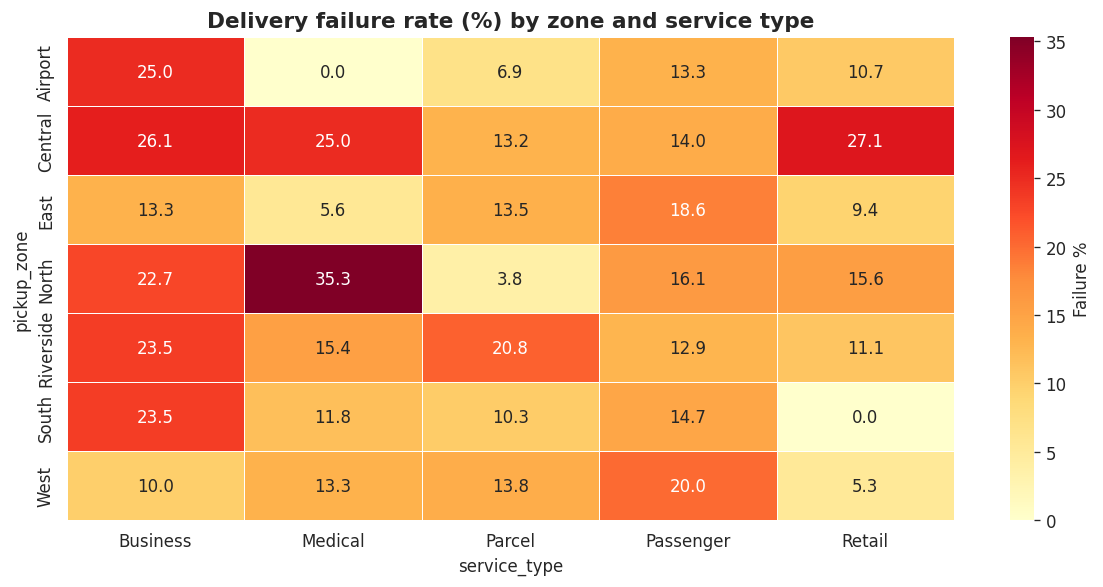

In [ ]:
# Figure 5.1 — Heatmap: zone × service_type failure rate
pivot = master.pivot_table(
    values='delivery_status',
    index='pickup_zone', columns='service_type',
    aggfunc=lambda s: 100 * (s == 'Failed').sum() / len(s)
).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Failure %'})
ax.set_title('Delivery failure rate (%) by zone and service type')
plt.tight_layout()
plt.show()

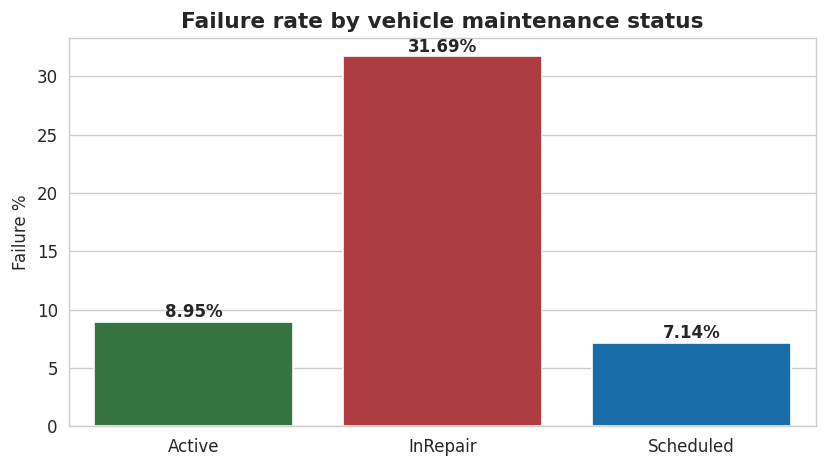

In [ ]:
# Figure 5.2 — The smoking gun (Python rendering)
maint = (master.groupby('maintenance_status')['delivery_status']
         .apply(lambda s: 100 * (s == 'Failed').mean()).round(2)
         .reset_index(name='failure_pct'))

plt.figure(figsize=(7, 4))
colours = {'Active': '#2A7F3A', 'Scheduled': '#0070C0', 'InRepair': '#C1292E'}
bars = sns.barplot(data=maint, x='maintenance_status', y='failure_pct',
                   palette=[colours[s] for s in maint['maintenance_status']])
for i, r in maint.iterrows():
    plt.text(i, r.failure_pct + 0.4, f'{r.failure_pct}%',
             ha='center', fontweight='bold')
plt.title('Failure rate by vehicle maintenance status')
plt.ylabel('Failure %'); plt.xlabel('')
plt.tight_layout(); plt.show()

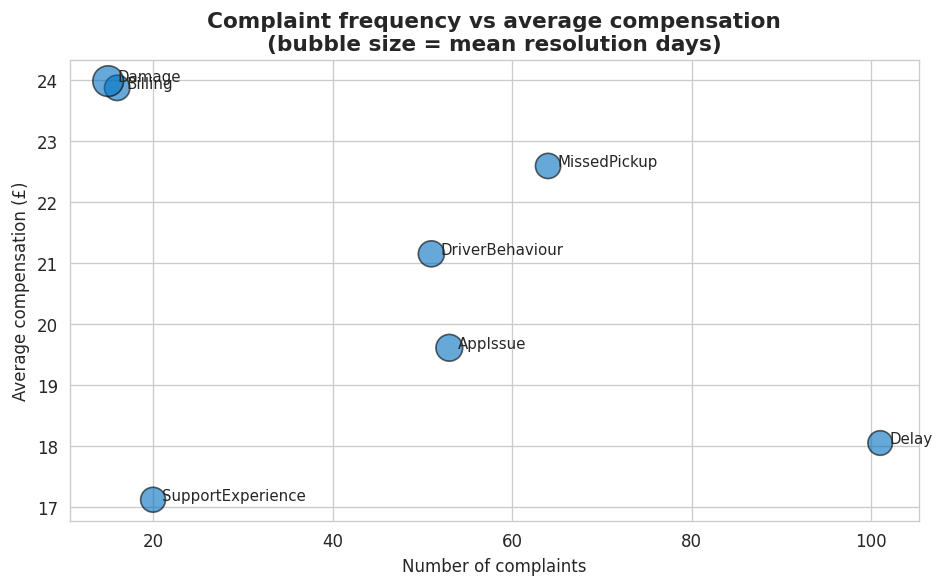

In [ ]:
# Figure 5.3 — Complaint frequency vs compensation (bubble = resolution days)
comp_summary = (complaints.groupby('complaint_type')
                .agg(n=('complaint_id', 'size'),
                     avg_comp=('compensation_amount', 'mean'),
                     avg_days=('resolution_days', 'mean'))
                .round(2).reset_index())

plt.figure(figsize=(8, 5))
plt.scatter(comp_summary['n'], comp_summary['avg_comp'],
            s=comp_summary['avg_days'] * 30, alpha=0.6,
            c='#0070C0', edgecolor='black')
for _, r in comp_summary.iterrows():
    plt.text(r.n + 1, r.avg_comp, r.complaint_type, fontsize=9)
plt.title('Complaint frequency vs average compensation\n(bubble size = mean resolution days)')
plt.xlabel('Number of complaints'); plt.ylabel('Average compensation (£)')
plt.tight_layout(); plt.show()

## 6. Save cleaned master to processed data folder

The cleaned master frame is exported for use by the MongoDB notebook.

In [ ]:
import os
os.makedirs('processed', exist_ok=True)
master.to_csv('processed/master_clean.csv', index=False)
print(f'Master saved: {len(master)} rows × {master.shape[1]} columns')

Master saved: 886 rows × 43 columns
